In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'capsule-vision-2024-challenge:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F5570165%2F9211836%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20241010%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20241010T103310Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D8bd00eef4c1cc9fd8e0f69aaf5a6845d1f8ee702f98c9f7f0e6b823bec2670749099d581f417a2301fb83c14552971996941d7aeeb8f0aad2e0f7c338520fe01767b336841a3f5e59985ddd538f620a81b479957b7f041e7981968f098da4ce20decf8ea1e051c85a0b719093d8d251f9f1902ba7c81dccfa6c304e16e6a8dedc50a1fb2d681d2f46f912a74c7430558df15d3abbfc24ded3629f13b055ff305eb4d8ef533f0f32db11275dd269a8dd51fb57aade624c69c44f066ac042a3bc5ebc4d9ad84489e701082bc603c7101a39569b34a1d60521a6b4741bf324cb4b8c3a2dfbc49c9fc67ef946434109dfb9c0141978bcbd937f2160802931ff2550a'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 401553198 bytes downloaded
Downloaded and uncompressed: capsule-vision-2024-challenge
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/39960e5e099a45ca_13401.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/6cb700585c4f4070_14865.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/fb86bc87d3874cd7_12434.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/3c8d5f0b90d7475d_5090.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/89cdd41258c542c5_13228.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/0728084c8da942d9_10972.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/dac1e27f7e4d4ef5_7536.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/c7084b3556e34619_29813.jpg
/kaggle/input/capsule-vision-2024-challenge/Dataset/validation/Normal/KVASIR/0531325b64674948_10102.jpg
/kaggle/input/c

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight


In [ ]:
train_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/training'

val_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/validation'

In [ ]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0)  # Rescale pixel values between 0 and 1
val_datagen = ImageDataGenerator(rescale=1.0/255.0)

print("In Training dataset")
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(224, 224),  # Image size (change as required)
    batch_size=32,
    class_mode='categorical',  # Multi-class labels
    shuffle=True
)


print("In Validation dataset")
val_generator = val_datagen.flow_from_directory(
    val_data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Class indices mapping
print("Class Indices:", train_generator.class_indices)

In Training dataset
Found 37607 images belonging to 10 classes.
In Validation dataset
Found 16132 images belonging to 10 classes.
Class Indices: {'Angioectasia': 0, 'Bleeding': 1, 'Erosion': 2, 'Erythema': 3, 'Foreign Body': 4, 'Lymphangiectasia': 5, 'Normal': 6, 'Polyp': 7, 'Ulcer': 8, 'Worms': 9}


In [ ]:
train_labels = train_generator.classes
val_labels = val_generator.classes

print(train_labels)
print(val_labels)


class_names = list(train_generator.class_indices.keys())
class_names

[0 0 0 ... 9 9 9]
[0 0 0 ... 9 9 9]


['Angioectasia',
 'Bleeding',
 'Erosion',
 'Erythema',
 'Foreign Body',
 'Lymphangiectasia',
 'Normal',
 'Polyp',
 'Ulcer',
 'Worms']

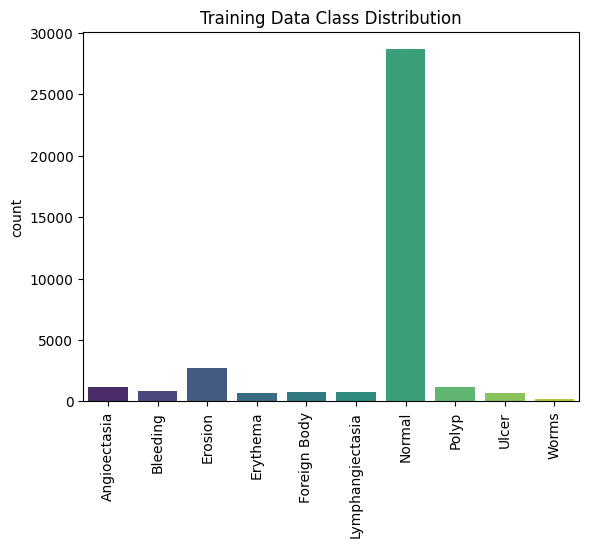

In [ ]:
sns.countplot(x=train_labels, palette="viridis")
plt.title('Training Data Class Distribution')
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=90)
plt.show()

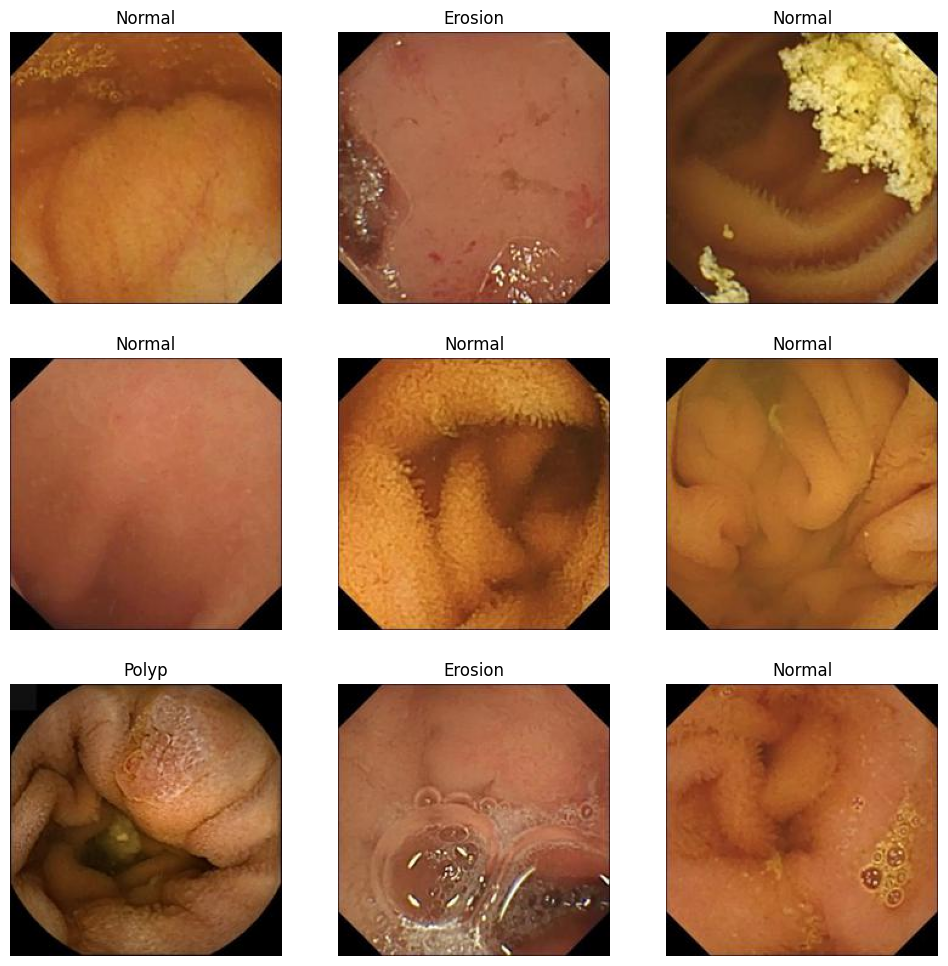

In [ ]:
def show_sample_images(generator):
    class_labels = list(generator.class_indices.keys())
    images, labels = next(generator)
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_labels[np.argmax(labels[i])])
        plt.axis('off')
    plt.show()

show_sample_images(train_generator)

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [ ]:
def extract_features(generator, model):
    # Extract features using the VGG16 model without the top layer
    features = model.predict(generator)
    return features, generator.classes

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
feature_model = Model(inputs=base_model.input, outputs=base_model.output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_features, train_labels = extract_features(train_generator, feature_model)

# Flatten the features for visualization
train_features_flatten = train_features.reshape(train_features.shape[0], -1)


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1176/1176 ━━━━━━━━━━━━━━━━━━━━ 158s 123ms/step


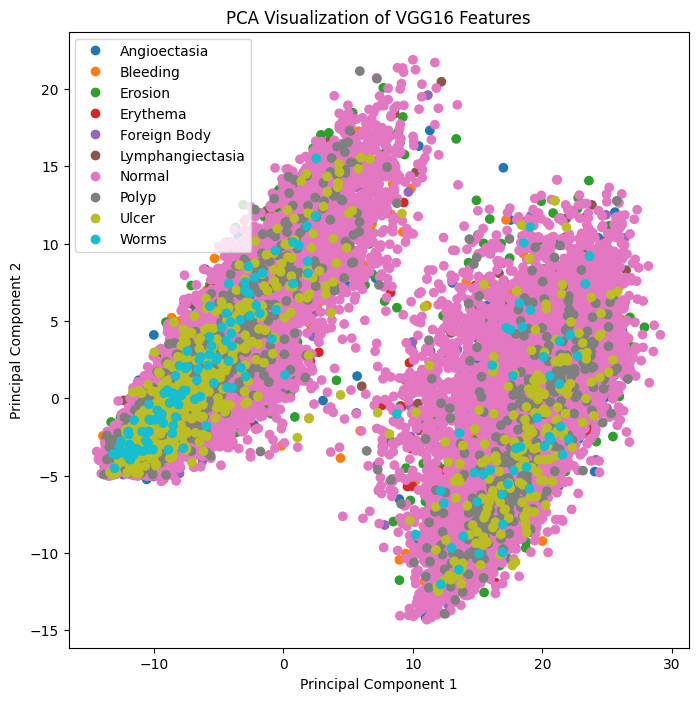

In [ ]:
def visualize_with_pca(features, labels, num_components=50):
    pca = PCA(n_components=num_components)
    pca_result = pca.fit_transform(features)

    plt.figure(figsize=(8, 8))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=labels, cmap='tab10')
    plt.title("PCA Visualization of VGG16 Features")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(handles=scatter.legend_elements()[0], labels=list(train_generator.class_indices.keys()))
    plt.show()

visualize_with_pca(train_features_flatten, train_labels)

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


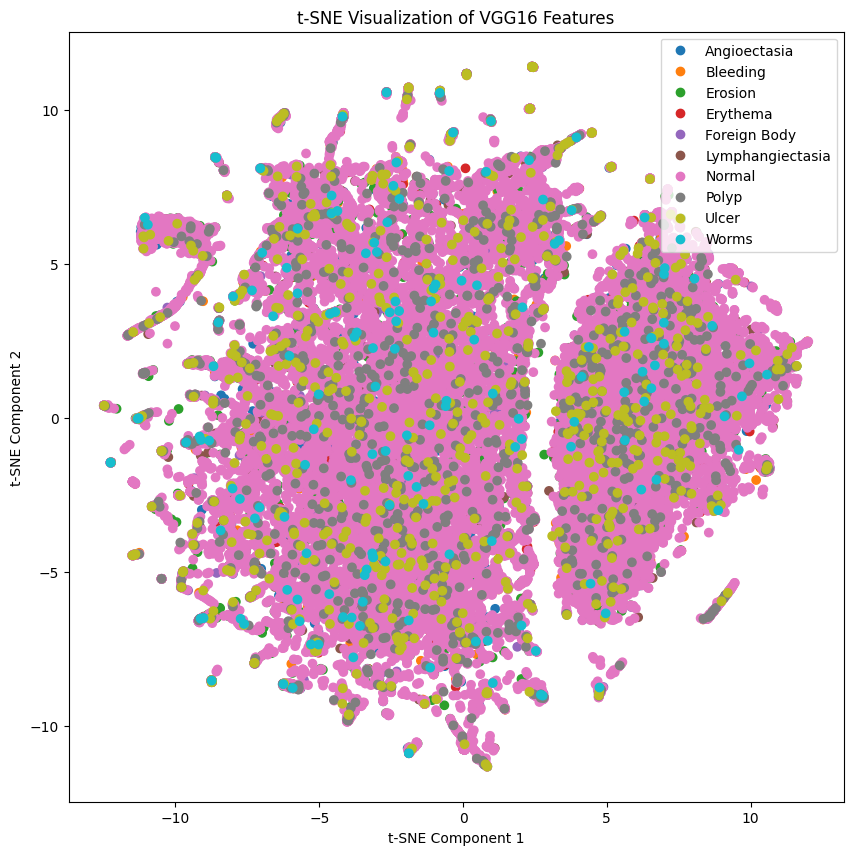

In [ ]:
def visualize_with_tsne(features, labels, n_iter=300):
    tsne = TSNE(n_iter=n_iter, n_components=2, perplexity=30)
    tsne_result = tsne.fit_transform(features)

    plt.figure(figsize=(10, 10))
    scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='tab10')
    plt.title("t-SNE Visualization of VGG16 Features")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend(handles=scatter.legend_elements()[0], labels=list(train_generator.class_indices.keys()))
    plt.show()

visualize_with_tsne(train_features_flatten, train_generator.classes)


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


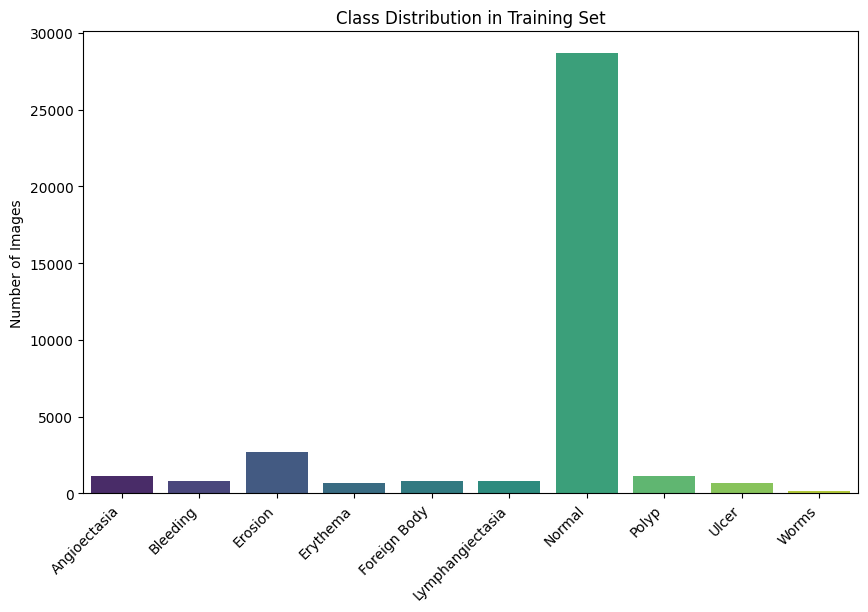

In [ ]:
import seaborn as sns

class_counts = {
    'Angioectasia': 1154,
    'Bleeding': 834,
    'Erosion': 2694,
    'Erythema': 691,
    'Foreign Body': 792,
    'Lymphangiectasia': 796,
    'Normal': 28663,
    'Polyp': 1162,
    'Ulcer': 663,
    'Worms': 158
}

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution in Training Set')
plt.ylabel('Number of Images')
plt.show()


Image Format: JPEG
Image Size (Width x Height): 224 x 224
Image Mode: RGB


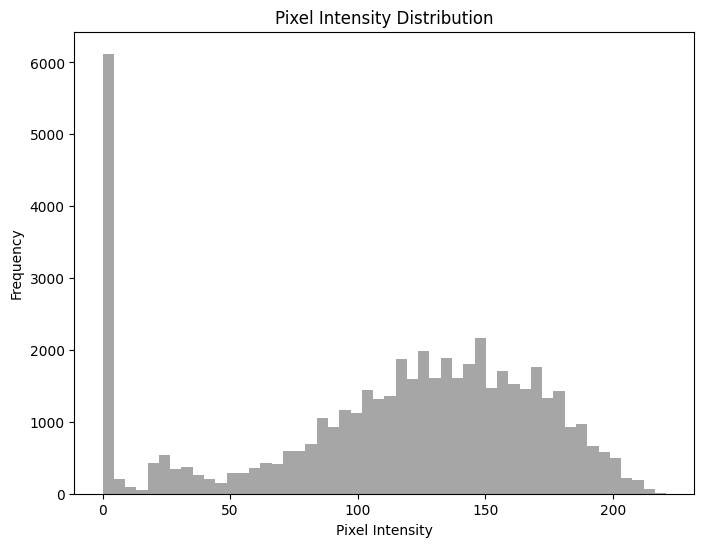

In [ ]:
import numpy as np
from PIL import Image


image_path = '/kaggle/input/capsule-vision-2024-challenge/Dataset/training/Angioectasia/KID/angioectasia-P0-1.jpg'
image = Image.open(image_path)

# Basic properties
width, height = image.size
color_mode = image.mode
format = image.format

print(f"Image Format: {format}")
print(f"Image Size (Width x Height): {width} x {height}")
print(f"Image Mode: {color_mode}")  # This tells us whether the image is grayscale or RGB

# Convert image to grayscale for pixel intensity analysis
gray_image = image.convert('L')  # 'L' mode converts the image to grayscale
gray_array = np.asarray(gray_image)

# Plot pixel intensity distribution
plt.figure(figsize=(8, 6))
plt.hist(gray_array.flatten(), bins=50, color='gray', alpha=0.7)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()


In [ ]:
!pip install -U scikit-image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 42.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.23.2
    Uninstalling scikit-image-0.23.2:
      Successfully uninstalled scikit-image-0.23.2


In [ ]:
import skimage
print(skimage.__version__)


0.23.2


In [ ]:
!pip install mahotas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 41.4 MB/s eta 0:00:0000:0100:01


In [ ]:
import mahotas as mh
import numpy as np
from PIL import Image

# Load the image
image = Image.open('/kaggle/input/capsule-vision-2024-challenge/Dataset/training/Angioectasia/KID/angioectasia-P0-1.jpg')

# Convert to grayscale
gray_image = np.array(image.convert('L'))

# Compute Haralick features
haralick_features = mh.features.haralick(gray_image).mean(axis=0)

# Display the features
print("Haralick features:")
print(haralick_features)


Haralick features:
[ 5.56164478e-03  6.68649928e+01  9.90057641e-01  3.36582468e+03
  3.12009666e-01  2.26981910e+02  1.33964337e+04  8.13981020e+00
  1.12938027e+01  4.88495970e-04  3.67303608e+00 -4.29386684e-01
  9.98872938e-01]


In [ ]:
import cv2
import numpy as np

def variance_of_laplacian(image):
    # Convert image to grayscale
    gray = np.array(image.convert('L'))
    # Compute the Laplacian of the image and return the variance
    return cv2.Laplacian(gray, cv2.CV_64F).var()

# Calculate blur score for the sample image
blur_score = variance_of_laplacian(image)
print(f"Blur score (higher = sharper): {blur_score}")

# Brightness is the mean of the pixel values
def calculate_brightness(image):
    gray = np.array(image.convert('L'))
    return np.mean(gray)

brightness = calculate_brightness(image)
print(f"Brightness: {brightness}")


Blur score (higher = sharper): 144.95388749300167
Brightness: 112.97885443239795


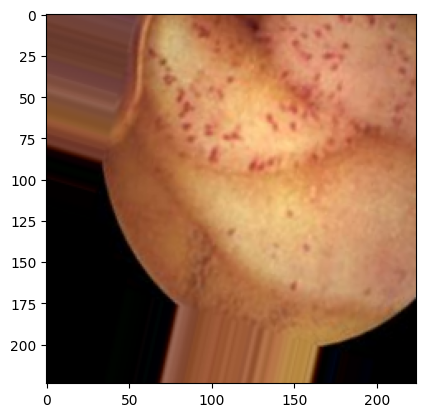

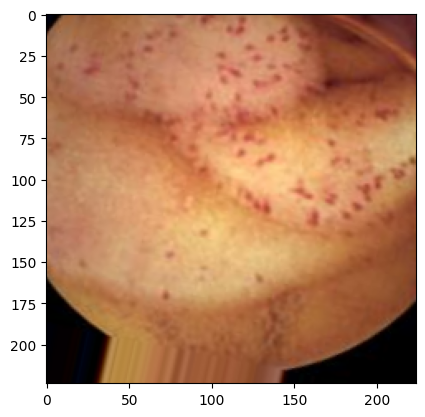

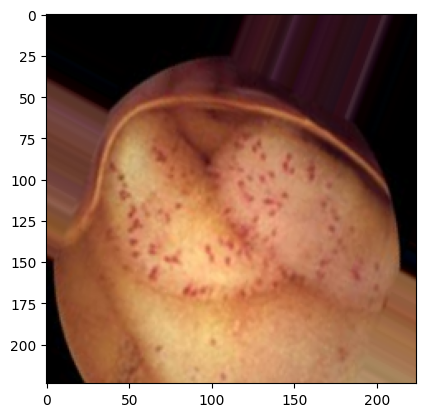

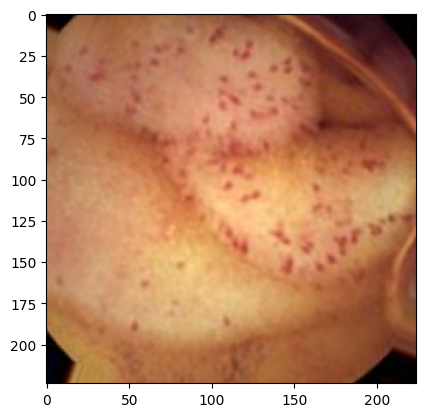

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load your image
image = Image.open("/kaggle/input/capsule-vision-2024-challenge/Dataset/training/Angioectasia/KID/angioectasia-P0-1.jpg")
image = np.array(image)

# Create an ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=40,         # Random rotation between 0-40 degrees
    width_shift_range=0.2,     # Horizontal shift
    height_shift_range=0.2,    # Vertical shift
    shear_range=0.2,           # Shear (skewing)
    zoom_range=0.2,            # Zoom in and out
    horizontal_flip=True,      # Flip the image horizontally
    fill_mode='nearest'        # Fill mode for pixels outside the input image
)

# Reshape image for ImageDataGenerator (need an extra dimension for batch)
image = np.expand_dims(image, 0)

# Generate augmented images
i = 0
for batch in datagen.flow(image, batch_size=1):
    plt.figure(i)
    img_plot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break  # Show only 4 augmentations
plt.show()


In [ ]:
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.3 MB/s eta 0:00:00


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image transformations for training and validation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.RandomHorizontalFlip(),  # Data augmentation
    transforms.RandomRotation(10),  # Randomly rotate the images
    transforms.ToTensor(),  # Convert the image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),  # Convert the image to PyTorch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet stats
])


In [ ]:
train_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/training'
val_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/validation'

# Load the training and validation datasets
train_dataset = datasets.ImageFolder(root=train_data_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=val_transforms)

In [ ]:
# Create DataLoader for training and validation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1, Train Loss: 0.38134127417555536, Train Accuracy: 87.9756428324514%, Val Loss: 0.26143611364886693, Val Accuracy: 91.70592610959584%
Validation loss improved!
Epoch 2, Train Loss: 0.2152733392023551, Train Accuracy: 92.88430345414417%, Val Loss: 0.20744407323388625, Val Accuracy: 92.96429456979915%
Validation loss improved!
Epoch 3, Train Loss: 0.16750788756697296, Train Accuracy: 94.39200148908448%, Val Loss: 0.21193666184891988, Val Accuracy: 92.72253905281428%
Epoch 4, Train Loss: 0.14302123695980998, Train Accuracy: 95.15781636397479%, Val Loss: 0.2128872912387056, Val Accuracy: 93.16885693032482%
Early stopping at epoch 4

Classification Report:

                  precision    recall  f1-score   support

    Angioectasia       0.86      0.71      0.78       497
        Bleeding       0.90      0.78      0.84       359
         Erosion       0.69      0.81      0.75      1155
        Erythema       0.65      0.41      0.50       297
    Foreign Body       0.91      0.85    

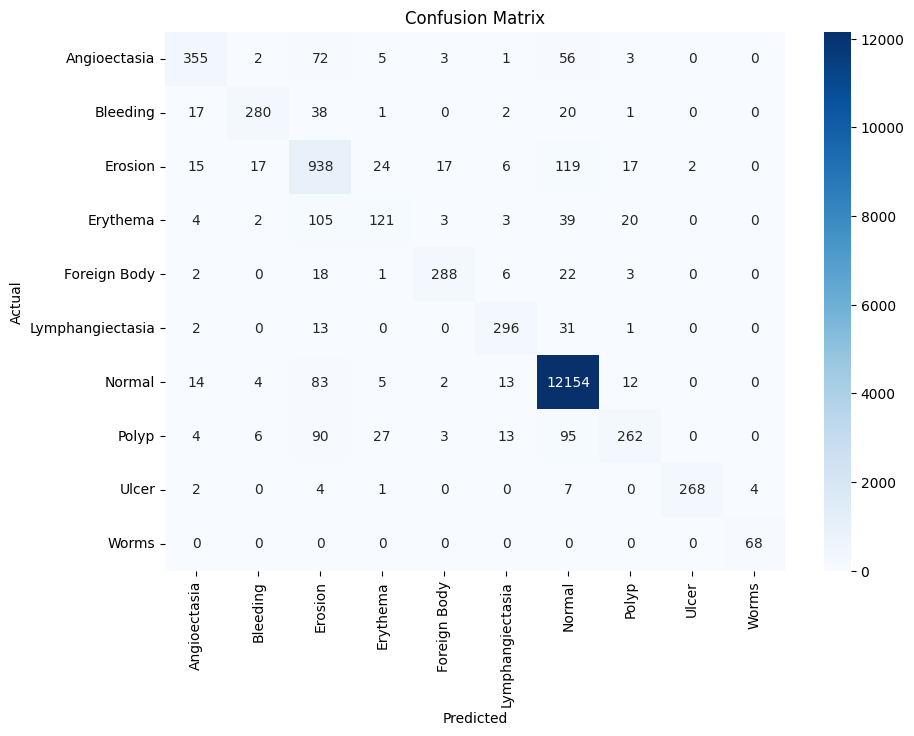

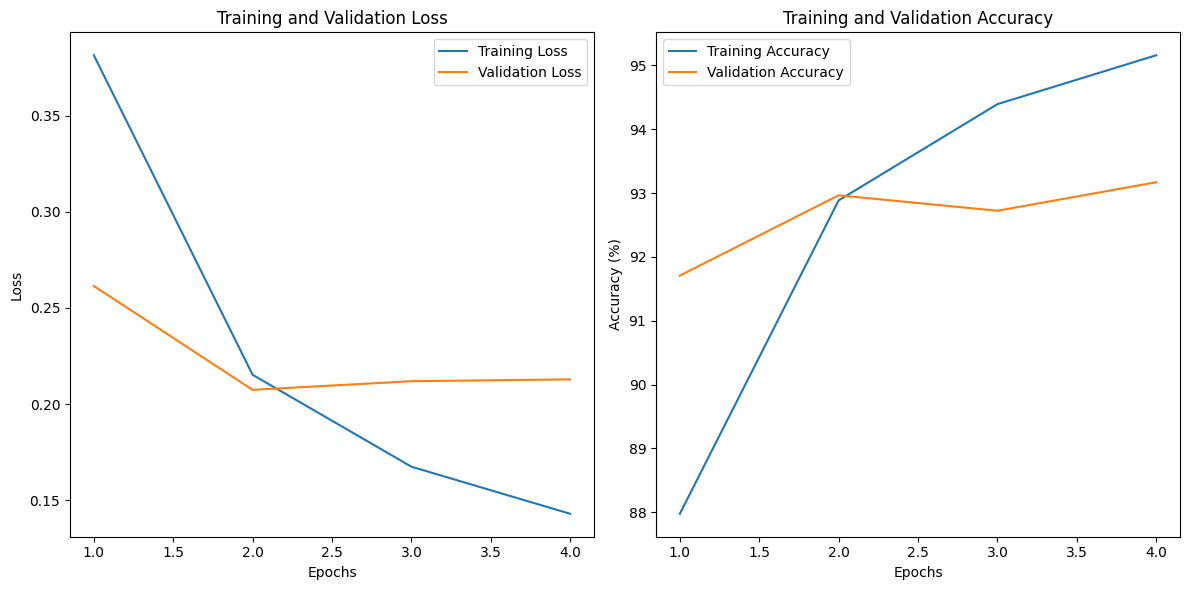

In [ ]:
import torch
import timm
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Pretrained Swin model
swin_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(swin_model.parameters(), lr=0.0001)

# Early stopping setup
patience = 2
best_val_loss = float('inf')
epochs_no_improve = 0

# Data transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Paths to data directories
train_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/training'
val_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/validation'

# Create datasets
train_dataset = datasets.ImageFolder(root=train_data_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Function to calculate accuracy
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)

# Training function
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_accuracy = 100 * correct / total
    return running_loss / len(train_loader), train_accuracy

# Validation function with metrics
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    return running_loss / len(val_loader), accuracy, all_labels, all_preds

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
swin_model.to(device)

# Initialize lists to store losses and accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training and validation loop
for epoch in range(10):
    train_loss, train_accuracy = train(swin_model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy, all_labels, all_preds = validate(swin_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f'Epoch {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_accuracy}%, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}%')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        print("Validation loss improved!")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

# Classification Report and Confusion Matrix
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plotting the losses and accuracies
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))

# Plot training and validation losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracies
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import torch
import timm
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Pretrained Swin model
swin_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(swin_model.parameters(), lr=0.0001)

# Early stopping setup
patience = 2
best_val_loss = float('inf')
epochs_no_improve = 0

# Data transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Paths to data directories
train_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/training'
val_data_dir = '/kaggle/input/capsule-vision-2024-challenge/Dataset/validation'

# Create datasets
train_dataset = datasets.ImageFolder(root=train_data_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=val_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Function to calculate accuracy
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)

# Training function
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_accuracy = 100 * correct / total
    return running_loss / len(train_loader), train_accuracy

# Validation function with metrics
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    return running_loss / len(val_loader), accuracy, all_labels, all_preds

# Initialize device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
swin_model.to(device)

# Initialize lists to store losses and accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training and validation loop
for epoch in range(10):
    train_loss, train_accuracy = train(swin_model, train_loader, criterion, optimizer, device)
    val_loss, val_accuracy, all_labels, all_preds = validate(swin_model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(f'Epoch {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_accuracy}%, Val Loss: {val_loss}, Val Accuracy: {val_accuracy}%')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        print("Validation loss improved!")
    else:
        epochs_no_improve += 1

    # if epochs_no_improve >= patience:
    #     print(f'Early stopping at epoch {epoch+1}')
    #     break

# Classification Report and Confusion Matrix
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

conf_matrix = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Plotting the losses and accuracies
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))

# Plot training and validation losses
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracies
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Epoch 1, Train Loss: 0.38646844522964185, Train Accuracy: 87.72568936634137%, Val Loss: 0.2705832245693174, Val Accuracy: 90.80709149516488%
Validation loss improved!
Epoch 2, Train Loss: 0.21661711584215945, Train Accuracy: 92.73539500624884%, Val Loss: 0.21266352889114554, Val Accuracy: 92.98909000743863%
Validation loss improved!
Epoch 3, Train Loss: 0.1676177963864717, Train Accuracy: 94.43986491876512%, Val Loss: 0.21002157085669176, Val Accuracy: 92.92090255393008%
Validation loss improved!
Epoch 4, Train Loss: 0.14429163399150874, Train Accuracy: 95.08602121945383%, Val Loss: 0.20722823690208983, Val Accuracy: 93.34862385321101%
Validation loss improved!
Epoch 5, Train Loss: 0.11893487582462704, Train Accuracy: 95.88906320631797%, Val Loss: 0.24748878713857, Val Accuracy: 92.62335730225638%
Epoch 6, Train Loss: 0.10564682913281766, Train Accuracy: 96.38099290025794%, Val Loss: 0.261399891223968, Val Accuracy: 92.61095958343665%
Epoch 7, Train Loss: 0.0922548909638739, Train Accu

In [ ]:
import torch
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Assuming swin_model is your pretrained model
swin_model.eval()

# To store features and labels
features_list = []
labels_list = []

# Extract features from the dataset
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        # Extract features from the model
        features = swin_model.forward_features(images)
        features_list.append(features.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

# Concatenate the features and labels
features_array = np.concatenate(features_list, axis=0)
labels_array = np.concatenate(labels_list, axis=0)

tsne = TSNE(n_components=2, random_state=42)
tsne_features = tsne.fit_transform(features_array)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels_array, cmap='tab10')
plt.colorbar(scatter)
plt.title('t-SNE Plot of Extracted Features')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('tSNE Dimension 2')
plt.show()

NameError: name 'swin_model' is not defined